# MLOps — Práctica: Product Failure Prediction

Este notebook cubre:
1. **Exploración de datos (EDA)** — entender qué tenemos antes de modelar
2. **Task 1** — predecir si un producto va a fallar
3. **Task 2** — detectar data drift entre train y test

## 0. Imports y configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Estilo de las gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías cargadas ✅')

Librerías cargadas ✅


## 1. Carga de datos

In [ ]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Test:  {test.shape[0]:,} filas × {test.shape[1]} columnas')

Train: 26,570 filas × 26 columnas
Test:  20,775 filas × 25 columnas


## 2. Exploración de datos (EDA)

Antes de entrenar cualquier modelo, hay que entender los datos: qué columnas hay, qué valores toman, si hay nulos, cómo se distribuye el target, etc.

### 2.1 Primeras filas y tipos de columnas

In [7]:
train.head()

,id,product_code,loading,attribute_0,attribute_1,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,...,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17,failure
0,0,A,80.10,material_7,material_8,9,5,7,8,4,...,10.672,15.859,17.594,15.193,15.029,NaN,13.034,14.684,764.100,0
1,1,A,84.89,material_7,material_8,9,5,14,3,3,...,12.448,17.947,17.915,11.755,14.732,15.425,14.395,15.631,682.057,0
2,2,A,82.43,material_7,material_8,9,5,12,1,5,...,12.715,15.607,NaN,13.798,16.711,18.631,14.094,17.946,663.376,0
3,3,A,101.07,material_7,material_8,9,5,13,2,6,...,12.471,16.346,18.377,10.020,15.250,15.562,16.154,17.172,826.282,0
4,4,A,188.06,material_7,material_8,9,5,9,2,8,...,10.337,17.082,19.932,12.428,16.182,12.760,13.153,16.412,579.885,0


In [8]:
# Resumen de tipos y valores no nulos
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26570 entries, 0 to 26569
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              26570 non-null  int64  
 1   product_code    26570 non-null  object 
 2   loading         26320 non-null  float64
 3   attribute_0     26570 non-null  object 
 4   attribute_1     26570 non-null  object 
 5   attribute_2     26570 non-null  int64  
 6   attribute_3     26570 non-null  int64  
 7   measurement_0   26570 non-null  int64  
 8   measurement_1   26570 non-null  int64  
 9   measurement_2   26570 non-null  int64  
 10  measurement_3   26189 non-null  float64
 11  measurement_4   26032 non-null  float64
 12  measurement_5   25894 non-null  float64
 13  measurement_6   25774 non-null  float64
 14  measurement_7   25633 non-null  float64
 15  measurement_8   25522 non-null  float64
 16  measurement_9   25343 non-null  float64
 17  measurement_10  25270 non-null 

### 2.2 Estadísticas descriptivas

In [9]:
train.describe().round(2)

,id,loading,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,measurement_3,measurement_4,measurement_5,...,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17,failure
count,26570.00,26320.00,26570.00,26570.00,26570.00,26570.00,26570.00,26189.00,26032.00,25894.00,...,25343.00,25270.00,25102.00,24969.00,24796.00,24696.00,24561.00,24460.00,24286.00,26570.00
mean,13284.50,127.83,6.75,7.24,7.42,8.23,6.26,17.79,11.73,17.13,...,11.43,16.12,19.17,11.70,15.65,16.05,15.00,16.46,701.27,0.21
std,7670.24,39.03,1.47,1.46,4.12,4.20,3.31,1.00,1.00,1.00,...,1.00,1.41,1.52,1.49,1.16,1.49,1.55,1.71,123.30,0.41
min,0.00,33.16,5.00,5.00,0.00,0.00,0.00,13.97,8.01,12.07,...,7.54,9.32,12.46,5.17,10.89,9.14,9.10,9.70,196.79,0.00
25%,6642.25,99.99,6.00,6.00,4.00,5.00,4.00,17.12,11.05,16.44,...,10.76,15.21,18.17,10.70,14.89,15.06,13.96,15.27,618.96,0.00
50%,13284.50,122.39,6.00,8.00,7.00,8.00,6.00,17.79,11.73,17.13,...,11.43,16.13,19.21,11.72,15.63,16.04,14.97,16.44,701.02,0.00
75%,19926.75,149.15,8.00,8.00,10.00,11.00,8.00,18.47,12.41,17.80,...,12.10,17.02,20.21,12.71,16.37,17.08,16.02,17.63,784.09,0.00
max,26569.00,385.86,9.00,9.00,29.00,29.00,24.00,21.50,16.48,21.42,...,15.41,22.48,25.64,17.66,22.71,22.30,21.63,24.09,1312.79,1.00


### 2.3 Variable target: ¿cuántos fallos hay?

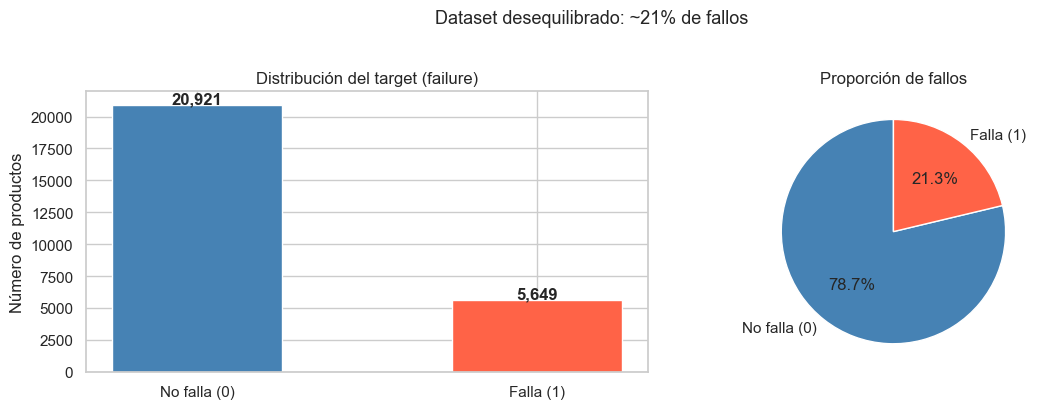

Tasa de fallos: 21.3%


In [10]:
counts = train['failure'].value_counts()
labels = ['No falla (0)', 'Falla (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(labels, counts.values, color=['steelblue', 'tomato'], width=0.5)
axes[0].set_title('Distribución del target (failure)')
axes[0].set_ylabel('Número de productos')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de fallos')

plt.suptitle('Dataset desequilibrado: ~21% de fallos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Tasa de fallos: {train["failure"].mean():.1%}')

### 2.4 Valores nulos

Muchos algoritmos no admiten nulos directamente. Hay que identificarlos y decidir qué hacer con ellos.

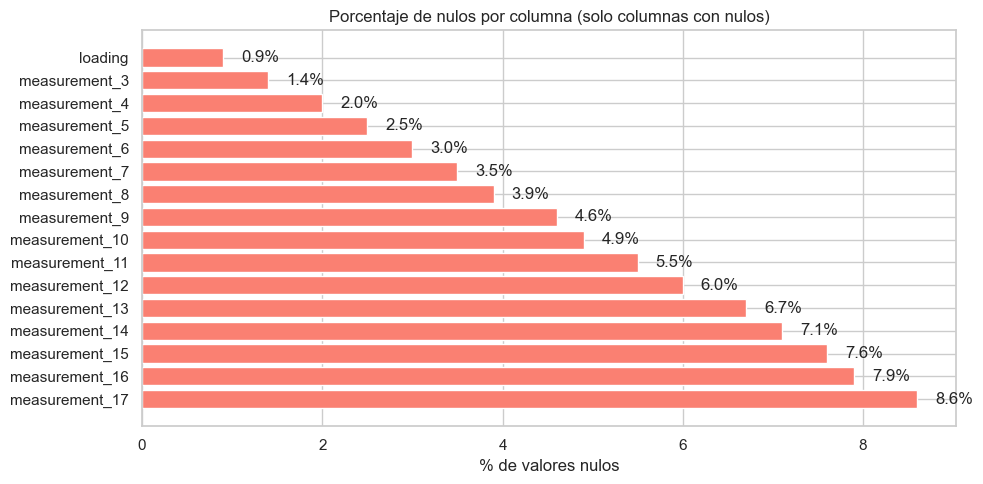

Las measurements tienen un patrón de nulos creciente — probablemente
no todos los productos se someten a todas las pruebas de laboratorio.


In [11]:
nulls = train.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
null_pct = (nulls / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nulls.index, null_pct.values, color='salmon')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de nulos por columna (solo columnas con nulos)')
for bar, pct in zip(bars, null_pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center')
plt.tight_layout()
plt.show()

print('Las measurements tienen un patrón de nulos creciente — probablemente')
print('no todos los productos se someten a todas las pruebas de laboratorio.')

### 2.5 Distribución por product_code

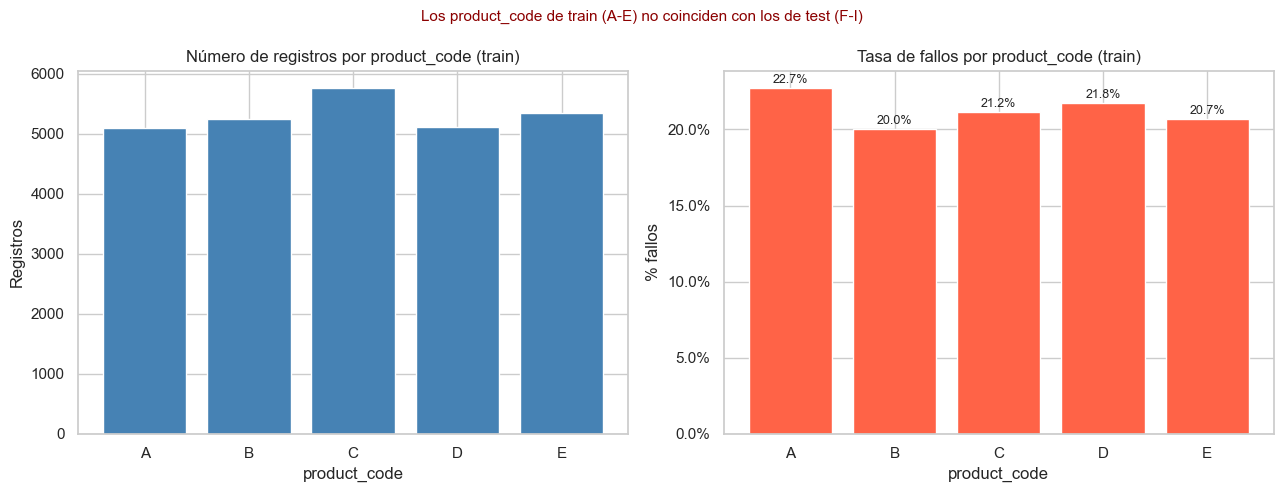

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Número de productos por código
code_counts = train['product_code'].value_counts().sort_index()
axes[0].bar(code_counts.index, code_counts.values, color='steelblue')
axes[0].set_title('Número de registros por product_code (train)')
axes[0].set_xlabel('product_code')
axes[0].set_ylabel('Registros')

# Tasa de fallos por código
failure_by_code = train.groupby('product_code')['failure'].mean() * 100
axes[1].bar(failure_by_code.index, failure_by_code.values, color='tomato')
axes[1].set_title('Tasa de fallos por product_code (train)')
axes[1].set_xlabel('product_code')
axes[1].set_ylabel('% fallos')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (code, val) in enumerate(failure_by_code.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Los product_code de train (A-E) no coinciden con los de test (F-I)', 
             fontsize=11, color='darkred')
plt.tight_layout()
plt.show()

### 2.6 Distribución de `loading` (la variable más importante)

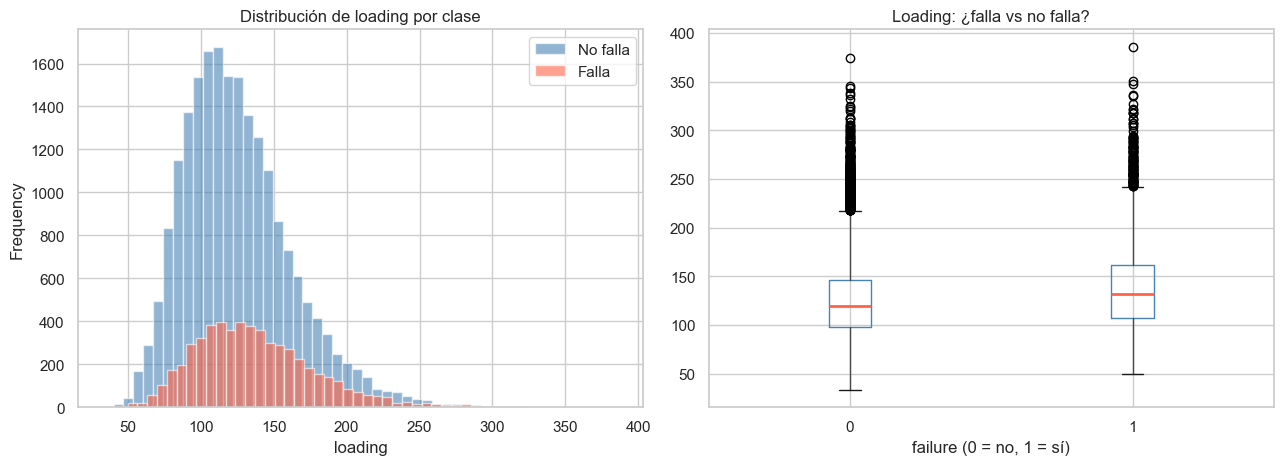

Los productos que fallan tienden a absorber más fluido (loading más alto)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma por clase
train[train['failure']==0]['loading'].dropna().plot.hist(
    bins=50, alpha=0.6, label='No falla', color='steelblue', ax=axes[0])
train[train['failure']==1]['loading'].dropna().plot.hist(
    bins=50, alpha=0.6, label='Falla', color='tomato', ax=axes[0])
axes[0].set_title('Distribución de loading por clase')
axes[0].set_xlabel('loading')
axes[0].legend()

# Boxplot
train.boxplot(column='loading', by='failure', ax=axes[1],
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Loading: ¿falla vs no falla?')
axes[1].set_xlabel('failure (0 = no, 1 = sí)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Los productos que fallan tienden a absorber más fluido (loading más alto)')

### 2.7 Correlación de features con el target

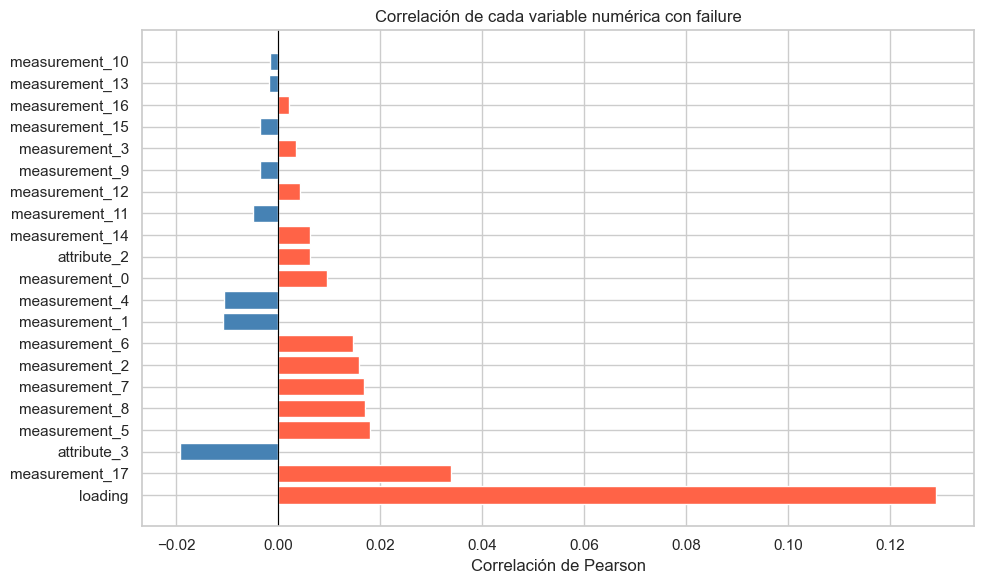

loading tiene la correlación más fuerte con el target.
Las measurements tienen correlaciones bajas pero no despreciables.


In [14]:
numeric_cols = train.select_dtypes(include='number').drop(columns=['id']).columns
correlations = train[numeric_cols].corr()['failure'].drop('failure').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable numérica con failure')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('loading tiene la correlación más fuerte con el target.')
print('Las measurements tienen correlaciones bajas pero no despreciables.')

---
## 3. TASK 1 — Predecir fallos de productos

**Objetivo:** entrenar un modelo con los datos de los productos A-E y predecir la probabilidad de fallo para los productos F-I del test set.

### 3.1 Preprocesamiento

In [15]:
# Separamos el target
y = train['failure']

# Guardamos los IDs para el output final
train_ids = train['id']
test_ids  = test['id']

# Quitamos columnas que no son features
train_data = train.drop(columns=['id', 'failure'])
test_data  = test.drop(columns=['id'])

# Combinamos para aplicar el mismo preprocesamiento a ambos datasets
combined = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

# Codificamos variables categóricas (texto → número)
for col in ['attribute_0', 'attribute_1', 'product_code']:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

# Rellenamos nulos con la mediana
combined = combined.fillna(combined.median(numeric_only=True))

# Separamos de nuevo
n_train = len(train_data)
X_train = combined.iloc[:n_train]
X_test  = combined.iloc[n_train:]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Nulos restantes: {X_train.isnull().sum().sum()}')

X_train: (26570, 24) | X_test: (20775, 24)
Nulos restantes: 0


### 3.2 Entrenamiento con validación cruzada

Usamos **5-fold cross-validation**: dividimos los datos de train en 5 partes iguales. En cada iteración, entrenamos con 4 partes y evaluamos con la restante. Esto nos da una estimación fiable del rendimiento real sin tocar el test set.

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y, cv=cv, scoring='roc_auc')

print('── Resultados Validación Cruzada ──')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: AUC = {score:.4f}')
print(f'  Media:  AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

── Resultados Validación Cruzada ──
  Fold 1: AUC = 0.5911
  Fold 2: AUC = 0.5815
  Fold 3: AUC = 0.5827
  Fold 4: AUC = 0.5792
  Fold 5: AUC = 0.5806
  Media:  AUC = 0.5830 ± 0.0042


### 3.3 Visualización del AUC por fold

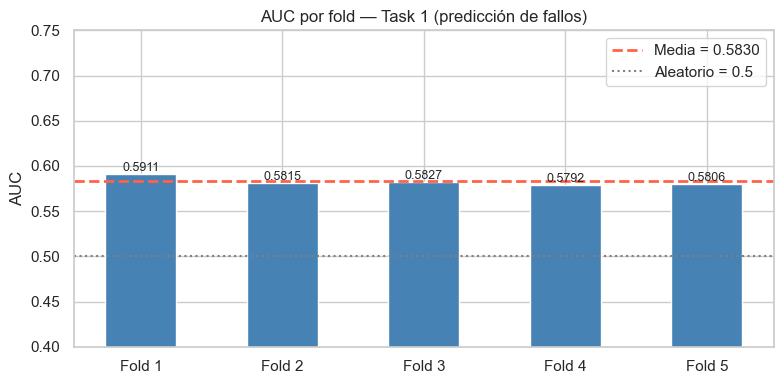

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
bars = ax.bar(folds, cv_scores, color='steelblue', width=0.5)
ax.axhline(cv_scores.mean(), color='tomato', linestyle='--', linewidth=2,
           label=f'Media = {cv_scores.mean():.4f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Aleatorio = 0.5')
ax.set_ylim(0.4, 0.75)
ax.set_ylabel('AUC')
ax.set_title('AUC por fold — Task 1 (predicción de fallos)')
ax.legend()
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 3.4 Importancia de variables

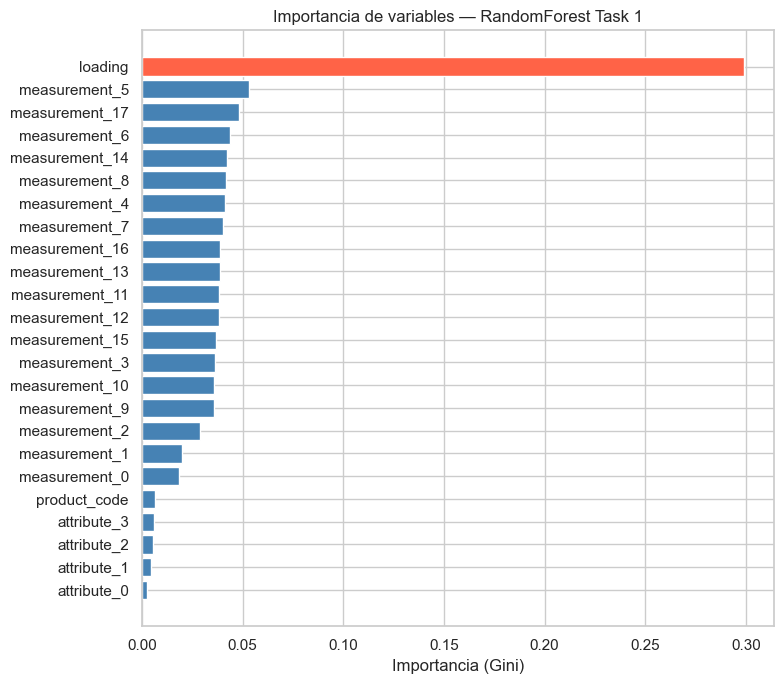

"loading" domina con 29.9% de importancia total.
El resto de variables contribuyen de forma mucho más modesta.


In [18]:
# Entrenamos con todos los datos para el modelo final
model.fit(X_train, y)

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['tomato' if c == importances.index[-1] else 'steelblue' for c in importances.index]
ax.barh(importances.index, importances.values, color=colors)
ax.set_title('Importancia de variables — RandomForest Task 1')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print(f'"loading" domina con {importances["loading"]:.1%} de importancia total.')
print('El resto de variables contribuyen de forma mucho más modesta.')

### 3.5 Predicciones y guardado

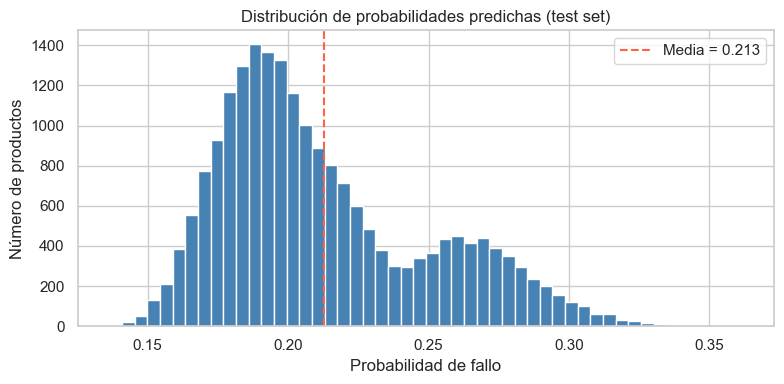

 Predicciones guardadas en outputs/predictions.csv
Las probabilidades se concentran en torno al 21.3%
(poca varianza → el modelo no está muy seguro de sus predicciones, señal del drift)


In [21]:
predictions = model.predict_proba(X_test)[:, 1]

output = pd.DataFrame({'id': test_ids, 'failure': predictions})
output.to_csv('/Users/Guille/Documents/MUIA/MLOps/mlops-practica/outputs/predictions.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(predictions, bins=50, color='steelblue', edgecolor='white')
ax.axvline(predictions.mean(), color='tomato', linestyle='--',
           label=f'Media = {predictions.mean():.3f}')
ax.set_title('Distribución de probabilidades predichas (test set)')
ax.set_xlabel('Probabilidad de fallo')
ax.set_ylabel('Número de productos')
ax.legend()
plt.tight_layout()
plt.show()

print(f' Predicciones guardadas en outputs/predictions.csv')
print(f'Las probabilidades se concentran en torno al {predictions.mean():.1%}')
print(f'(poca varianza → el modelo no está muy seguro de sus predicciones, señal del drift)')

---
## 4. TASK 2 — Detección de Data Drift

**Idea clave:** si mezclamos train y test en un solo dataset y etiquetamos de dónde viene cada fila, ¿puede un modelo aprender a distinguirlos?

- **Si AUC ≈ 0.5** → el modelo no puede distinguirlos → los datos son homogéneos → **sin drift**
- **Si AUC ≈ 1.0** → el modelo los distingue perfectamente → los datos son muy distintos → **drift severo**

### 4.1 Construir el dataset combinado

In [22]:
train_clean = train.drop(columns=['id', 'failure']).copy()
test_clean  = test.drop(columns=['id']).copy()

train_clean['origin'] = 0  # viene de train
test_clean['origin']  = 1  # viene de test

combined_drift = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)

y_drift    = combined_drift['origin']
X_drift    = combined_drift.drop(columns=['origin'])

# Mismo preprocesamiento
for col in ['attribute_0', 'attribute_1', 'product_code']:
    le = LabelEncoder()
    X_drift[col] = le.fit_transform(X_drift[col].astype(str))
X_drift = X_drift.fillna(X_drift.median(numeric_only=True))

print(f'Dataset combinado: {X_drift.shape}')
print(f'Etiqueta 0 (train): {(y_drift==0).sum():,} filas')
print(f'Etiqueta 1 (test):  {(y_drift==1).sum():,} filas')

Dataset combinado: (47345, 24)
Etiqueta 0 (train): 26,570 filas
Etiqueta 1 (test):  20,775 filas


### 4.2 Entrenar el modelo detector de drift

In [23]:
model_drift = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

cv_drift = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_drift_scores = cross_val_score(model_drift, X_drift, y_drift,
                                  cv=cv_drift, scoring='roc_auc')

print('── ¿Puede el modelo distinguir train de test? ──')
for i, score in enumerate(cv_drift_scores, 1):
    print(f'  Fold {i}: AUC = {score:.4f}')
print(f'  Media:  AUC = {cv_drift_scores.mean():.4f} ± {cv_drift_scores.std():.4f}')

── ¿Puede el modelo distinguir train de test? ──
  Fold 1: AUC = 1.0000
  Fold 2: AUC = 1.0000
  Fold 3: AUC = 1.0000
  Fold 4: AUC = 1.0000
  Fold 5: AUC = 1.0000
  Media:  AUC = 1.0000 ± 0.0000


### 4.3 Visualización del AUC de drift vs referencia

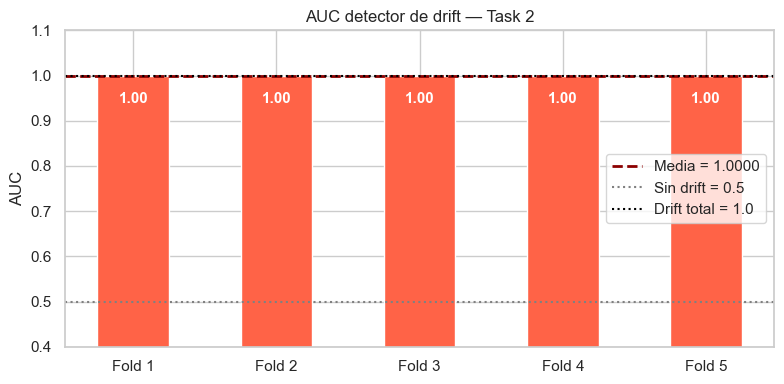

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
bars = ax.bar(folds, cv_drift_scores, color='tomato', width=0.5)
ax.axhline(cv_drift_scores.mean(), color='darkred', linestyle='--', linewidth=2,
           label=f'Media = {cv_drift_scores.mean():.4f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Sin drift = 0.5')
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.5, label='Drift total = 1.0')
ax.set_ylim(0.4, 1.1)
ax.set_ylabel('AUC')
ax.set_title('AUC detector de drift — Task 2')
ax.legend()
for bar, score in zip(bars, cv_drift_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.06,
            f'{score:.2f}', ha='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 ¿Qué variables causan el drift?

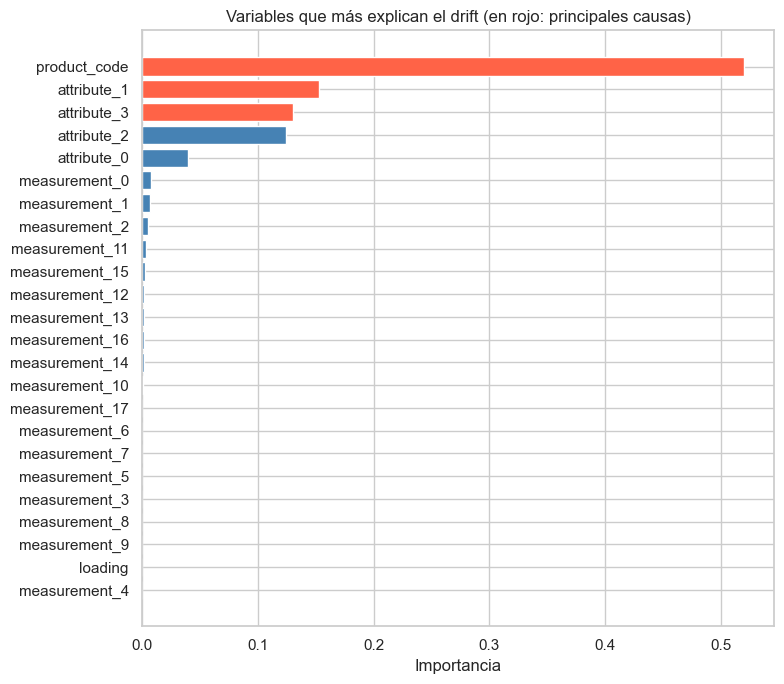

Las variables en rojo son las que más diferencian train de test.
product_code por sí solo es suficiente para separar ambos datasets.


In [25]:
model_drift.fit(X_drift, y_drift)

imp_drift = pd.Series(model_drift.feature_importances_, index=X_drift.columns)
imp_drift = imp_drift.sort_values(ascending=True)

# Colorear las top 3 causantes del drift
top3 = imp_drift.nlargest(3).index
colors = ['tomato' if c in top3 else 'steelblue' for c in imp_drift.index]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_drift.index, imp_drift.values, color=colors)
ax.set_title('Variables que más explican el drift (en rojo: principales causas)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Las variables en rojo son las que más diferencian train de test.')
print('product_code por sí solo es suficiente para separar ambos datasets.')

### 4.5 Comparación de distribuciones: train vs test

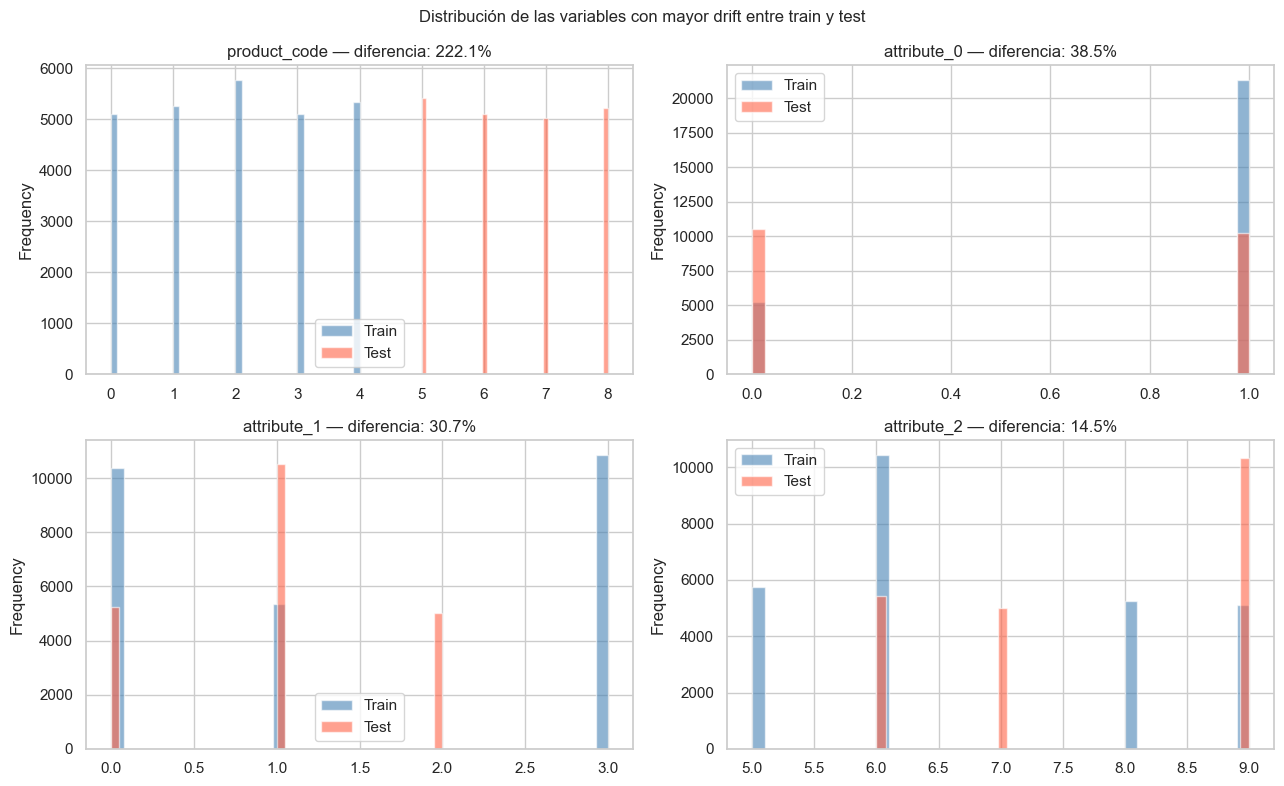

In [26]:
# Mostramos las 4 variables numéricas con mayor diferencia entre datasets
numeric_features = X_drift.select_dtypes(include='number').columns.tolist()
train_means = X_drift.loc[y_drift==0, numeric_features].mean()
test_means  = X_drift.loc[y_drift==1, numeric_features].mean()
diff = ((test_means - train_means) / train_means.abs() * 100).abs().sort_values(ascending=False)
top_diff_cols = diff.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_diff_cols):
    X_drift.loc[y_drift==0, col].plot.hist(
        bins=40, alpha=0.6, label='Train', color='steelblue', ax=ax)
    X_drift.loc[y_drift==1, col].plot.hist(
        bins=40, alpha=0.6, label='Test', color='tomato', ax=ax)
    ax.set_title(f'{col} — diferencia: {diff[col]:.1f}%')
    ax.legend()

plt.suptitle('Distribución de las variables con mayor drift entre train y test',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Conclusiones

### Task 1
El modelo obtiene un **AUC ≈ 0.58** en validación cruzada. Es ligeramente mejor que el azar (0.5), pero lejos de lo deseable. La variable `loading` domina completamente sobre el resto. El rendimiento modesto se explica en gran parte por el drift detectado en Task 2.

### Task 2
El modelo detector de drift obtiene **AUC = 1.0**: distingue train de test con precisión perfecta. Esto confirma que ambos datasets pertenecen a distribuciones muy distintas:
- Los `product_code` de train (A-E) y test (F-I) no se solapan
- Los atributos físicos de los productos también difieren sistemáticamente

### Respuesta a la pregunta del profesor
| Situación | AUC detector de drift | Significado |
|---|---|---|
| **Sin drift** | ≈ 0.5 | Train y test son indistinguibles. El modelo de Task 1 generalizará bien. |
| **Con drift (nuestro caso)** | ≈ 1.0 | Los datasets son mundos distintos. El modelo aprendió patrones que no aplican al test. El AUC de Task 1 real será peor de lo que indica la validación cruzada. |